In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## load the feature dataset
df=pd.read_excel('/Users/subasrees/Pediatric-cancer-analysis/feature_matrix_RS.xlsx',index_col=0)

In [2]:
import sklearn
sklearn.__version__ 

'1.8.0'

In [3]:
## drop this feature, denominator of this log ratio uses a oxidative phosphorylation reaction
df=df.drop(columns=["ATP_Gly_vs_ATP_Carbon__log_ratio"])

In [4]:
df["Fraction"] = pd.to_numeric(df["Fraction"], errors="coerce")
# divide the classes into normoxia, hypoxia and extreme hypoxia depending on the oxygen fractions
# ----- 3-class mapping -----
normoxia = {1.0, 0.5}
hypoxia  = {0.2,0.1, 0.05,0.02}
anoxia   = {0.01,0.005,0.002,0.001}

def frac_to_state(f):
    if f in normoxia: return "Normoxia"
    if f in hypoxia:  return "Hypoxia"
    if f in anoxia:   return "Extreme hypoxia"
    return np.nan

df["O2State"] = df["Fraction"].map(frac_to_state)

# Keep only rows we can label
df = df.dropna(subset=["O2State"]).copy()

# Feature columns: exclude metadata/labels; keep numeric only
meta_cols = {"Model","Fraction","Cancer","FractionLabel","O2State","Hypoxia"}
feature_cols = [c for c in df.columns if c not in meta_cols]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

print("Rows:", len(df), "Features:", len(feature_cols))
print(df["O2State"].value_counts())


Rows: 1470 Features: 100
O2State
Extreme hypoxia    588
Hypoxia            588
Normoxia           294
Name: count, dtype: int64


In [5]:
## load all necessary libraries from scikit
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [6]:
# confusion matrix 
def plot_confmat(
    y_true,
    y_pred,
    title="Confusion matrix",
    savepath=None,
    show=True
):
    labels = np.unique(y_true)

    fig, ax = plt.subplots(figsize=(4.8, 3.8))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    disp.plot(values_format="d", ax=ax)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)
    ax.set_title(title)
    plt.xticks(rotation=30,ha='right',fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()

    # SAVE
    if savepath is not None:
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
        os.path.join(savepath, f"{fname}.pdf"),
        dpi=300,
        bbox_inches="tight")
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
        os.path.join(savepath, f"{fname}.jpg"),
        dpi=300,
        bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


In [7]:
# AUC-ROC curves
def plot_roc(model, X_test, y_test, title="ROC",savepath=None,show=True):
    classes = np.unique(y_test)
    n_classes = len(classes)
    if not hasattr(model, "predict_proba"):
        print(f"[ROC skipped] {title}: model has no predict_proba")
        return

    y_prob = model.predict_proba(X_test)

    plt.figure(figsize=(7,5))

    if n_classes == 2:
        # positive class = classes[1]
        y_true_bin = (y_test == classes[1]).astype(int)
        fpr, tpr, _ = roc_curve(y_true_bin, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
        plt.plot([0,1],[0,1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(title)
        plt.legend()
        plt.tight_layout()
        plt.show()
        return

    # Multiclass: one-vs-rest
    y_bin = label_binarize(y_test, classes=classes)   # shape (n_samples, n_classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    #plt.show()
    # SAVE
    if savepath is not None:
        os.makedirs(savepath, exist_ok=True)
        fname = title.replace(" ", "_").lower()
        plt.savefig(
            os.path.join(savepath, f"{fname}.pdf"),
            dpi=300,
            bbox_inches="tight")
        plt.savefig(
            os.path.join(savepath, f"{fname}.jpg"),
            dpi=300,
            bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)



In [8]:
X = df[feature_cols].copy()   #DATAFRAME
y = df["O2State"]  # O2State for multiclass

In [9]:
# do imputing and scaling of data
preprocess = [
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("scaler", StandardScaler())
]

In [10]:
# choose 6 well known ML models
models = {
    "LogReg": Pipeline(preprocess + [
        ("clf", LogisticRegression(
            C=1.0, solver="lbfgs",
            class_weight="balanced",
            max_iter=2000
        ))
    ]),
    "SVM_RBF": Pipeline(preprocess + [
        ("clf", SVC(
            kernel="rbf",
            C=5.0, gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "RF": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("clf", RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "GB": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("clf", GradientBoostingClassifier(random_state=42))
    ]),
    "HGB": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05, max_depth=6, max_iter=400,
            random_state=42
        ))
    ]),
    "LGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("clf", LGBMClassifier(
            objective="multiclass",
            num_class=3,
            n_estimators=400,
            learning_rate=0.05,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            class_weight="balanced",
            verbose=-1,
            force_row_wise=True
        ))
])
}

In [11]:
# splitting traing and test, along with a validation set from training set
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42
)
# 60% train, 20% val, 20% test


In [12]:
from sklearn.preprocessing import LabelEncoder

# 1) Fit encoder on y_train
le = LabelEncoder()
y_train_full_enc = le.fit_transform(y_train_full)
y_train_enc = le.fit_transform(y_train)
y_val_enc  = le.transform(y_val)  # must transform test too
y_test_enc  = le.transform(y_test)  # must transform test too

# Check
print(le.classes_)  # ['Extreme hypoxia', 'Hypoxia', 'Normoxia']
print(np.unique(y_train_enc))  # [0, 1, 2]

['Extreme hypoxia' 'Hypoxia' 'Normoxia']
[0 1 2]



LogReg VALIDATION macro-F1 = 0.7032


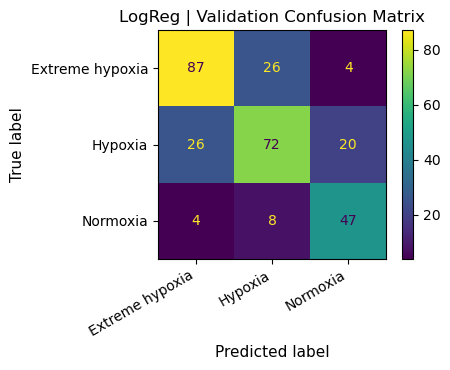


SVM_RBF VALIDATION macro-F1 = 0.7265


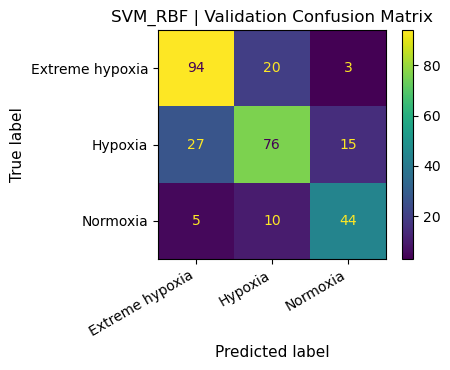


RF VALIDATION macro-F1 = 0.8271


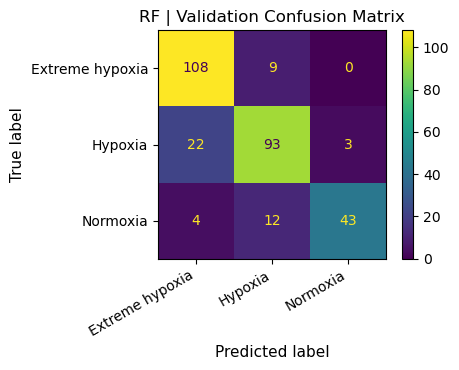


GB VALIDATION macro-F1 = 0.7946


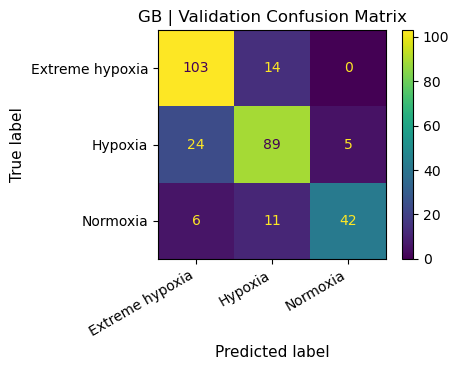


HGB VALIDATION macro-F1 = 0.8423


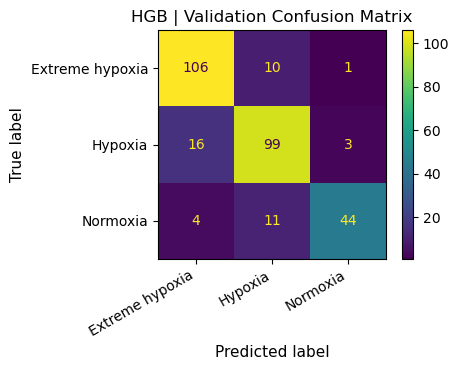


LGBM VALIDATION macro-F1 = 0.8365


/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


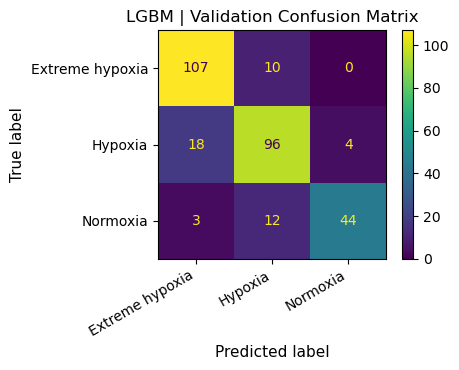

In [13]:
stageA = {}

for name, pipe in models.items():
    if name == 'XGB':
        pipe.fit(X_train, y_train_enc)  # encoded labels
        y_val_pred_enc = pipe.predict(X_val)
        y_val_pred = le.inverse_transform(y_val_pred_enc)
        y_true = y_val
    else:
        pipe.fit(X_train, y_train)
        y_val_pred = pipe.predict(X_val)
        y_true = y_val

    mf1 = f1_score(y_true, y_val_pred, average="macro")
    stageA[name] = {"pipe": pipe, "macro_f1": mf1}

    print("\n" + "="*70)
    print(name, "VALIDATION macro-F1 =", round(mf1, 4))

    plot_confmat(
        y_true, y_val_pred,
        title=f"{name} | Validation Confusion Matrix")


In [14]:
ranked = sorted(stageA.items(), key=lambda kv: kv[1]["macro_f1"], reverse=True)

print("\nTop models by VALIDATION macro-F1:")
for n, out in ranked:
    print(n, round(out["macro_f1"], 4))


Top models by VALIDATION macro-F1:
HGB 0.8423
LGBM 0.8365
RF 0.8271
GB 0.7946
SVM_RBF 0.7265
LogReg 0.7032


In [15]:
top3_names = [ranked[i][0] for i in range(min(3, len(ranked)))]
top3_names


['HGB', 'LGBM', 'RF']

In [16]:
param_grids = {
    "LogReg": {
        "clf__C": [0.1, 1.0, 10.0]
    },
    "SVM_RBF": {
        "clf__C": [1, 5, 10],
        "clf__gamma": ["scale", 0.1, 0.01]
    },
    "RF": {
        "clf__n_estimators": [300, 500],
        "clf__max_depth": [None, 10, 20]
    },
    "GB": {
        "clf__learning_rate": [0.05, 0.1],
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [2, 3]
    },
    "HGB": {
        "clf__learning_rate": [0.03, 0.05, 0.1],
        "clf__max_depth": [4, 6, None],
        "clf__max_iter": [200, 400]
    },
    "LGBM": {
        "clf__n_estimators": [200, 400],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [-1, 4, 6],     # -1 = no limit
        "clf__subsample": [0.8],
        "clf__colsample_bytree": [0.8],
        "clf__num_leaves": [31, 63],
    }
}


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}

for name in top3_names:
    base_pipe = models[name]
    grid = param_grids.get(name, None)

    if grid is None:
        print(f"\n{name}: no param grid provided, skipping tuning.")
        best_models[name] = base_pipe
        continue

    print("\n" + "="*70)
    print("Tuning:", name)

    gs = GridSearchCV(
        base_pipe,
        param_grid=grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    if name=='XGB':
        gs.fit(X_train_full, y_train_full_enc)
    else:
        gs.fit(X_train_full, y_train_full)

    print("Best CV macro-F1:", round(gs.best_score_, 4))
    print("Best params:", gs.best_params_)

    best_models[name] = gs.best_estimator_



Tuning: HGB
Best CV macro-F1: 0.8572
Best params: {'clf__learning_rate': 0.03, 'clf__max_depth': None, 'clf__max_iter': 200}

Tuning: LGBM


/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13

Best CV macro-F1: 0.8664
Best params: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 200, 'clf__num_leaves': 31, 'clf__subsample': 0.8}

Tuning: RF
Best CV macro-F1: 0.8343
Best params: {'clf__max_depth': None, 'clf__n_estimators': 300}



HGB TEST macro-F1 = 0.8257
HGB Macro AUC: 0.9645


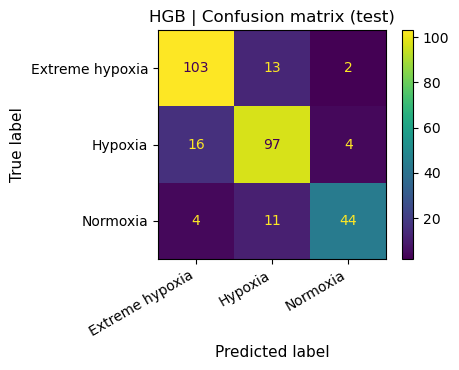

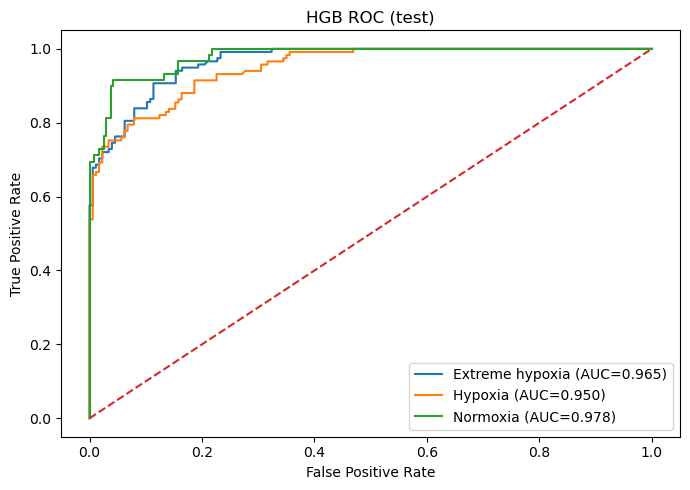


LGBM TEST macro-F1 = 0.8362
LGBM Macro AUC: 0.9644


/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


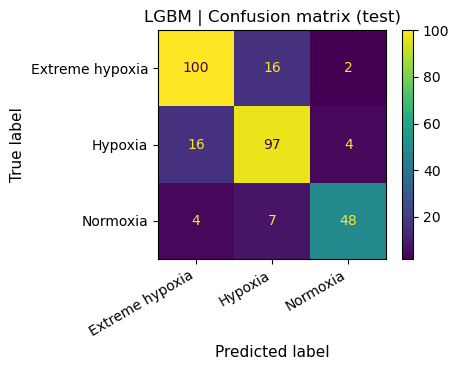

/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


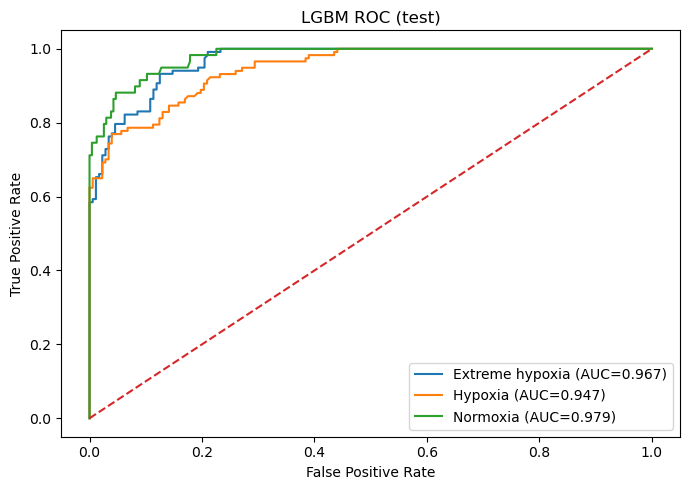


RF TEST macro-F1 = 0.8373
RF Macro AUC: 0.9378


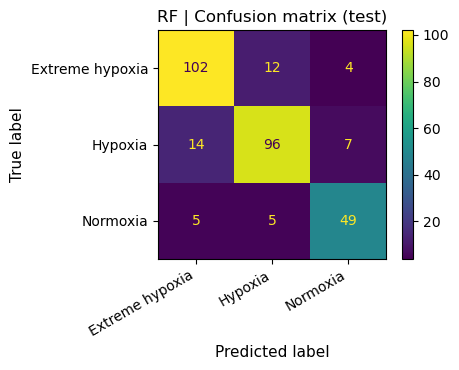

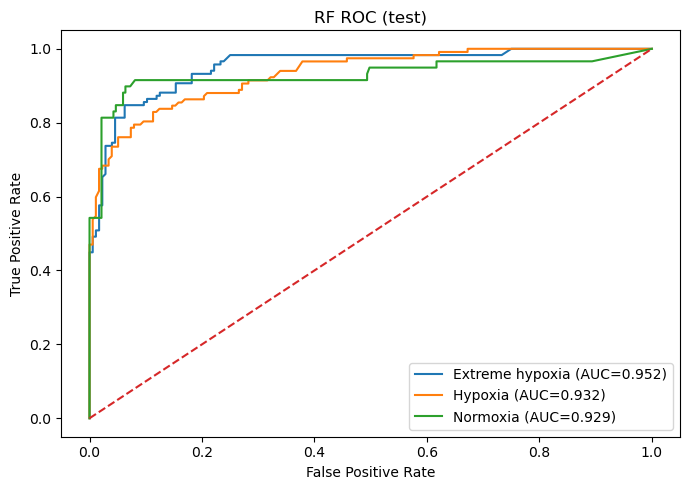

In [18]:
from sklearn.metrics import roc_auc_score
#savepath='/Users/subasrees/Pediatric-cancer-analysis/Figs/'
for name, pipe in best_models.items():
    if name=='XGB':
        y_pred_enc = pipe.predict(X_test)
        mf1 = f1_score(y_test_enc, y_pred_enc, average="macro")

        print("\n" + "="*70)
        print(name, "TEST macro-F1 =", round(mf1, 4))

        plot_confmat(y_test_enc, y_pred_enc, title=f"{name} | Confusion matrix (test)", savepath=None,show=True)
        plot_roc(pipe, X_test, y_test_enc, title=f"{name} ROC (test)",savepath=None,show=True)
    else:
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)
        mf1 = f1_score(y_test, y_pred, average="macro")

        print("\n" + "="*70)
        print(name, "TEST macro-F1 =", round(mf1, 4))
        macro_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="macro")
        print(name,"Macro AUC:", round(macro_auc,4))
        plot_confmat(y_test, y_pred, title=f"{name} | Confusion matrix (test)", savepath=None,show=True)
        plot_roc(pipe, X_test, y_test, title=f"{name} ROC (test)",savepath=None,show=True)



In [19]:
class_names = le.classes_
pipe_lgbm=best_models['LGBM']
pipe_hgb = best_models["HGB"]
pipe_rf=best_models["RF"]

In [20]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import os

## shap analysis for all the 3 models to get Global feature importance,Class-specific feature importance and shap.Explanation
def shap_any_model_multiclass_with_importance(
    pipe,
    X_train_df: pd.DataFrame,
    X_test_df: pd.DataFrame,
    class_names,
    model_name: str,
    background_size: int = 100,
    random_state: int = 42,
    make_plots: bool = False,
    savepath: str | None = None,
    max_evals: int = 2000,   # controls runtime for model-agnostic explainers
):
    class_names = list(class_names)
    feat_names = list(X_test_df.columns)

    rng = np.random.default_rng(random_state)

    # Background subset from TRAIN
    bg_n = min(background_size, len(X_train_df))
    bg_idx = rng.choice(len(X_train_df), size=bg_n, replace=False)
    X_bg = X_train_df.iloc[bg_idx]

    # Explain ALL test rows
    X_te = X_test_df

    # Explain probabilities directly (so SHAP is in Δprobability space)
    explainer = shap.Explainer(pipe.predict_proba, X_bg, seed=random_state)
    shap_exp = explainer(X_te, max_evals=max_evals)

    # ---- sanity checks ----
    if not isinstance(shap_exp.values, np.ndarray):
        raise TypeError(f"Expected shap_exp.values to be ndarray, got {type(shap_exp.values)}")

    if shap_exp.values.ndim != 3:
        raise ValueError(f"Expected shap_exp.values shape (n,f,c), got {shap_exp.values.shape}")

    n, f, c = shap_exp.values.shape
    if f != len(feat_names):
        raise ValueError(f"Feature count mismatch: SHAP has {f}, X_te has {len(feat_names)}")
    if c != len(class_names):
        raise ValueError(f"Class count mismatch: SHAP has {c}, class_names has {len(class_names)}")

    # ---------- 1) Global importance ----------
    global_vals = np.mean(np.abs(shap_exp.values), axis=(0, 2))  # mean over samples and classes
    imp_global = pd.Series(global_vals, index=feat_names).sort_values(ascending=False)

    # ---------- 2) Class-specific importance ----------
    imp_per_class = {}
    for k, cls in enumerate(class_names):
        class_vals = np.mean(np.abs(shap_exp.values[:, :, k]), axis=0)
        imp_per_class[cls] = pd.Series(class_vals, index=feat_names).sort_values(ascending=False)

        if make_plots:
            shap.summary_plot(
                shap_exp.values[:, :, k],
                features=X_te,                # keep DataFrame
                feature_names=feat_names,
                show=False
            )
            plt.title(f"{model_name} | SHAP summary | {cls}")
            plt.tight_layout()

            if savepath is not None:
                os.makedirs(savepath, exist_ok=True)
                safe_cls = cls.replace(" ", "_")
                safe_model = model_name.replace(" ", "_")
                fname = f"shap_summary_{safe_model}_{safe_cls}"
                plt.savefig(os.path.join(savepath, f"{fname}.pdf"), dpi=300, bbox_inches="tight")
                plt.savefig(os.path.join(savepath, f"{fname}.jpg"), dpi=300, bbox_inches="tight")

            plt.show()

    return imp_global, imp_per_class, shap_exp


PermutationExplainer explainer: 295it [07:40,  1.58s/it]                         
/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


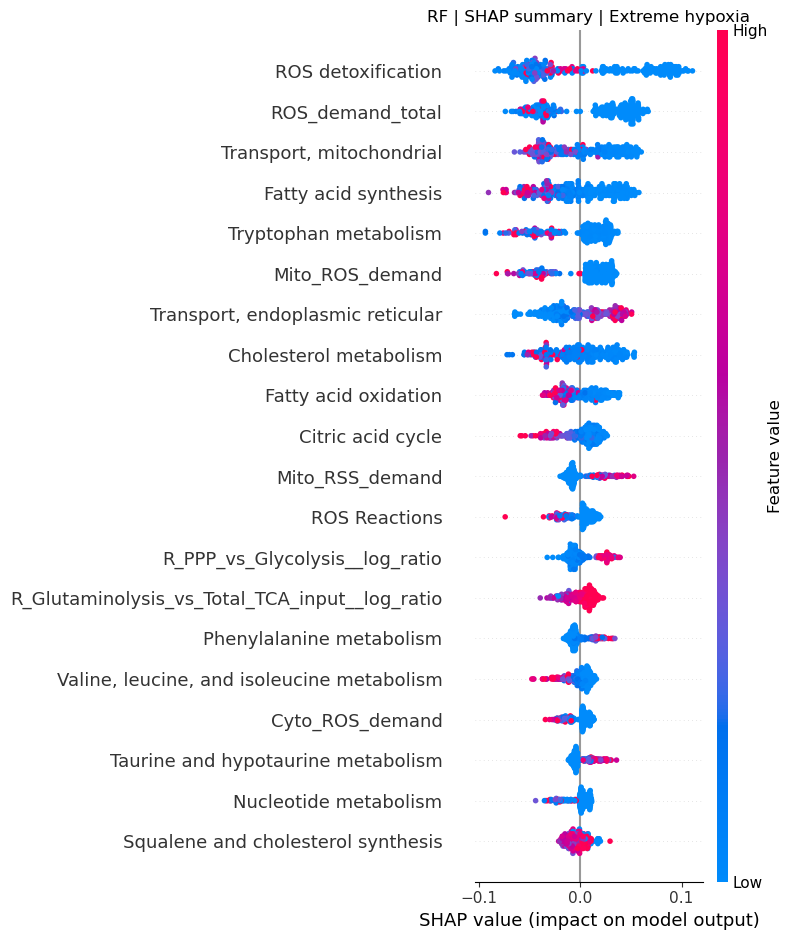

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


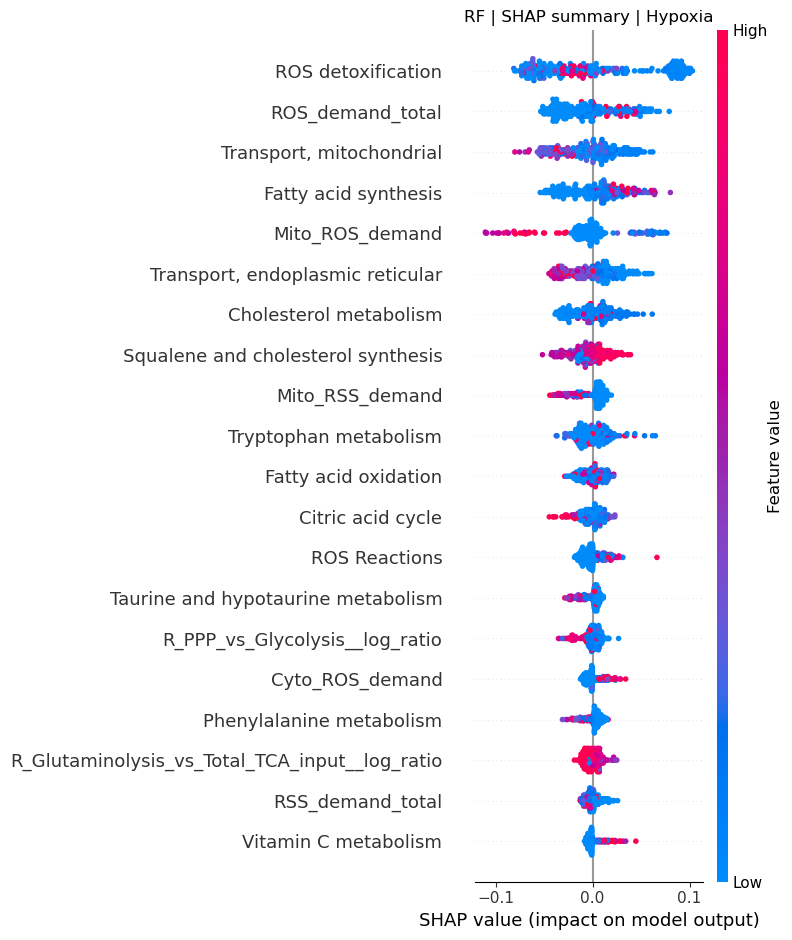

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


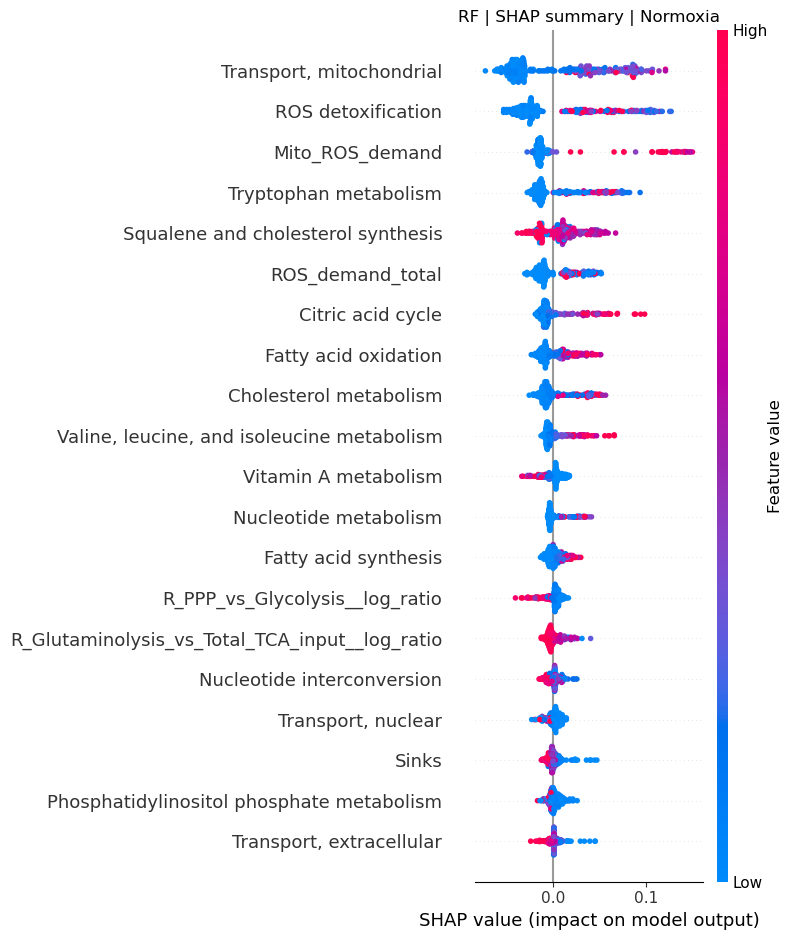

PermutationExplainer explainer: 295it [19:39,  4.04s/it]                         
/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


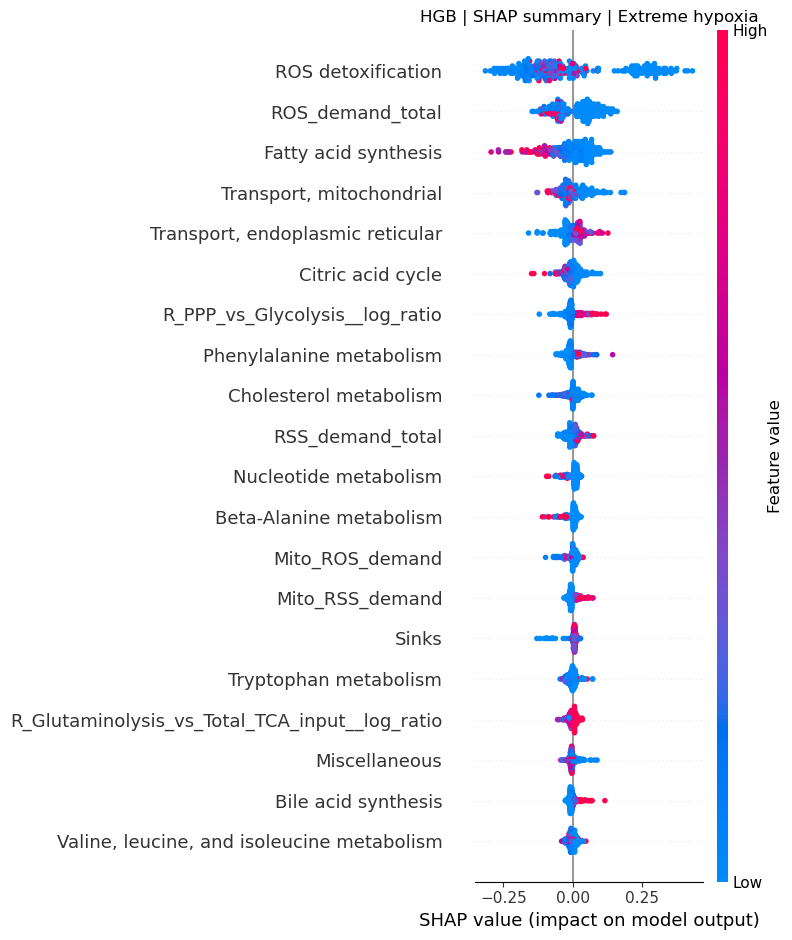

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


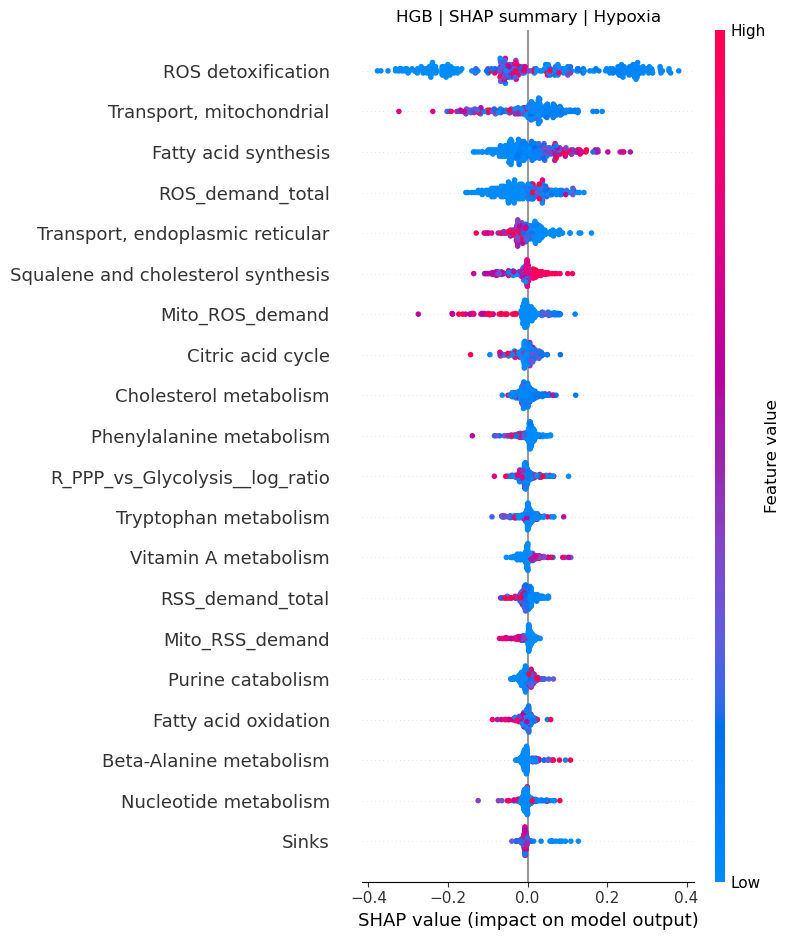

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


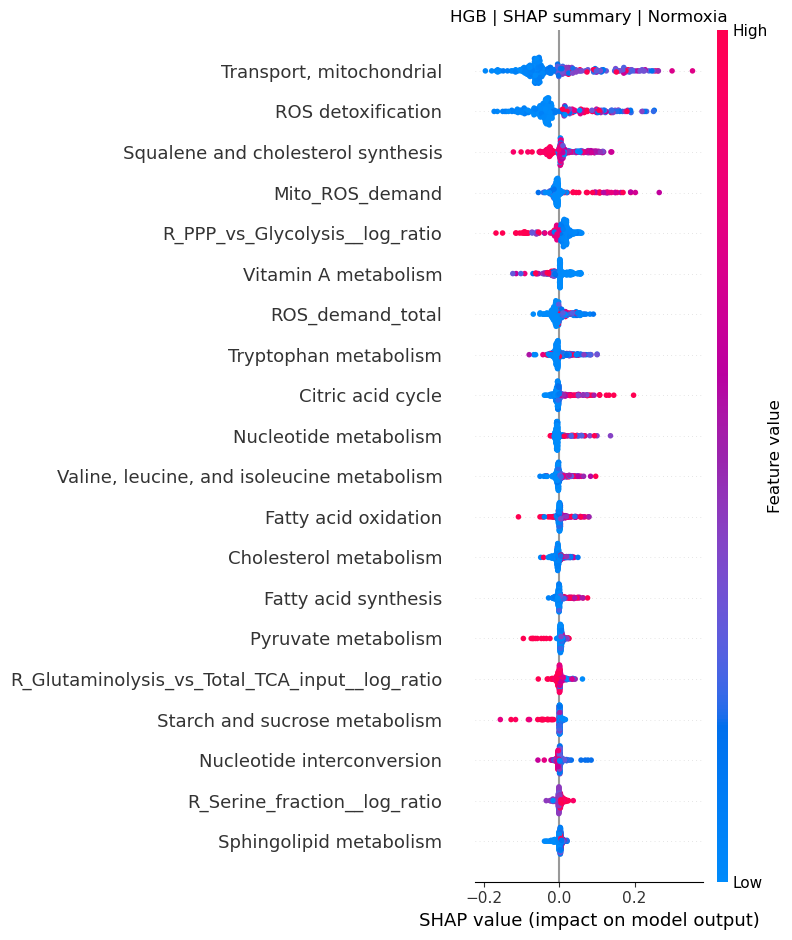

/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/subasrees/Desktop/anaconda3/envs/python_latest/lib/python3.13

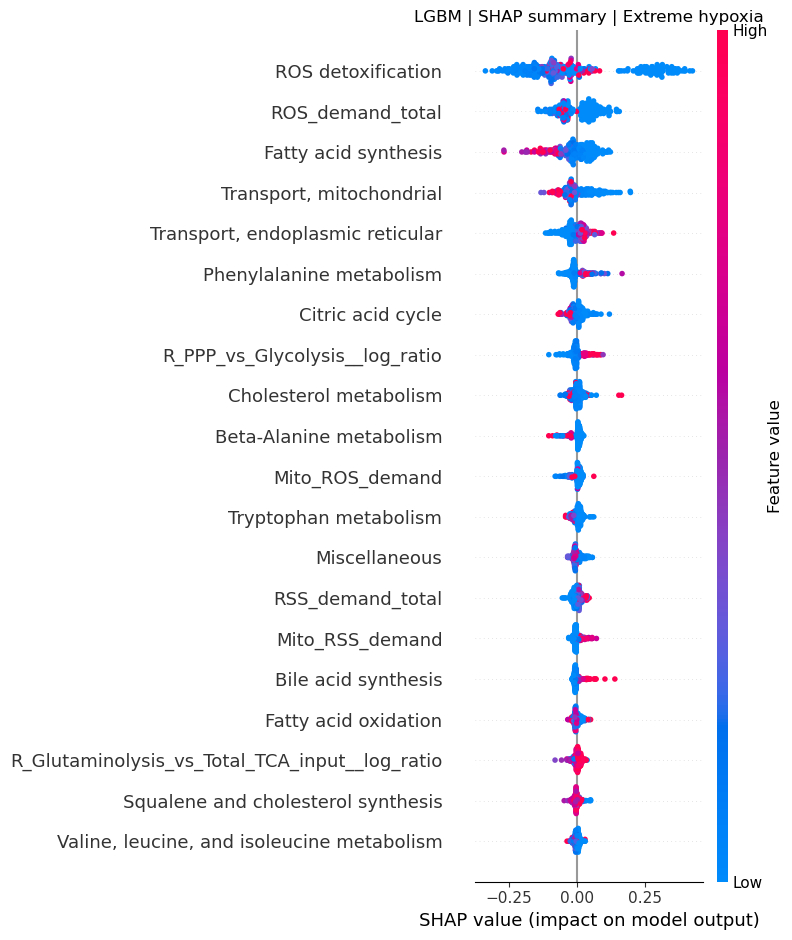

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


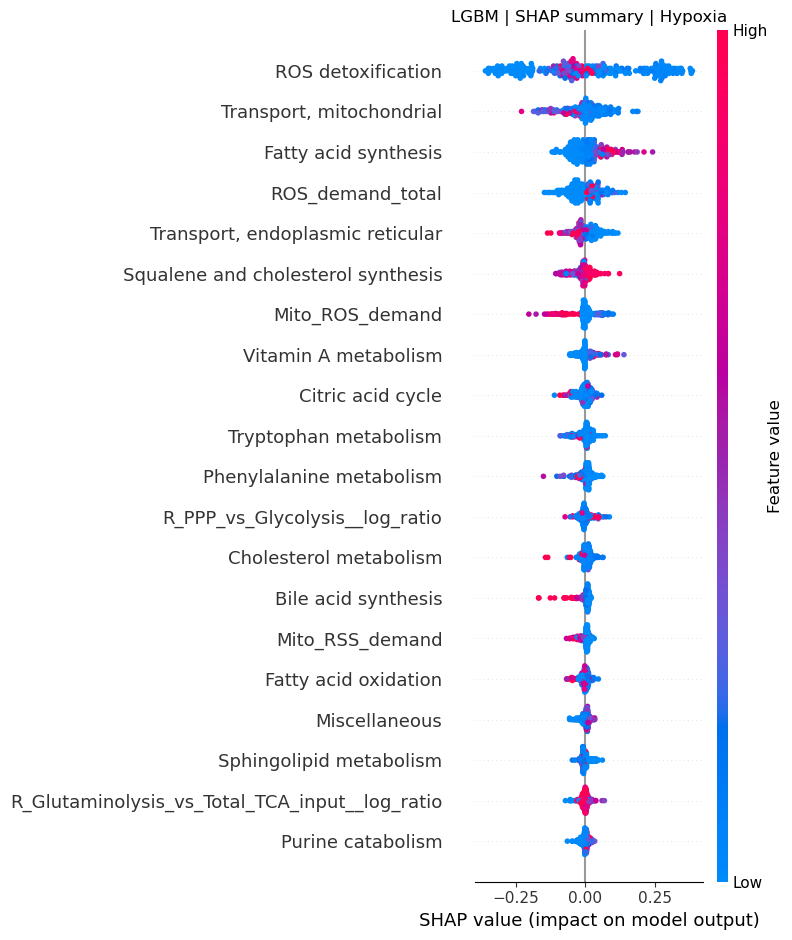

/var/folders/yl/47vnp0617dn9zfv19_vrxwjh0000gn/T/ipykernel_35133/1877294806.py:73: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


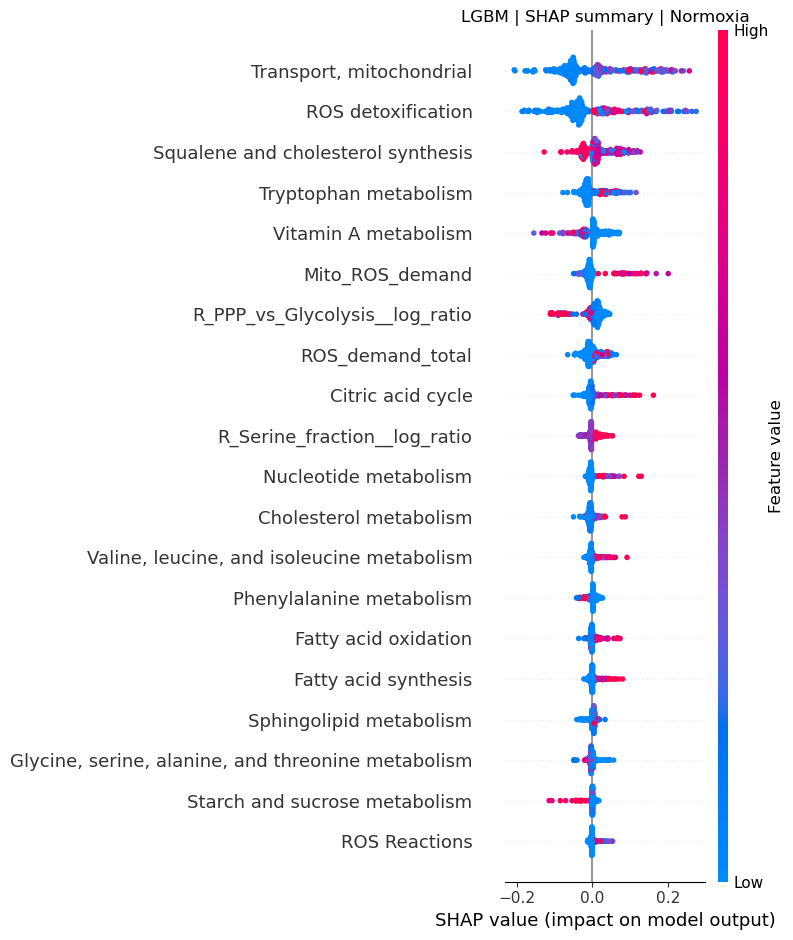

In [21]:
rf_imp_global, rf_imp_class, rf_shap = shap_any_model_multiclass_with_importance(
    pipe_rf, X_train_full, X_test, le.classes_,model_name='RF',make_plots=True,savepath=None,
)

hgb_imp_global, hgb_imp_class, hgb_shap = shap_any_model_multiclass_with_importance(
    pipe_hgb, X_train_full, X_test, le.classes_,model_name='HGB',make_plots=True,savepath=None,
)
lgbm_imp_global, lgbm_imp_class, lgbm_shap = shap_any_model_multiclass_with_importance(
   pipe_lgbm, X_train_full, X_test, le.classes_,model_name='LGBM',make_plots=True,savepath=None,
)

gb_imp_global, gb_imp_class, gb_shap = shap_any_model_multiclass_with_importance(
   pipe_gb, X_train_full, X_test, le.classes_,model_name='GB',make_plots=True,savepath=savepath,
)

In [22]:
## get globally important features from all three models
imp_dict_prob = {
    "RF":rf_imp_global,
    "HGB": hgb_imp_global,
    #"GB":gb_imp_global,
    "LGBM":lgbm_imp_global
}

In [ ]:
# get consensus features
shap_exp=lgbm_shap
top_feats = list(set(imp_dict_prob['HGB'].index[:20])&set(imp_dict_prob['LGBM'].index[:20])&set(imp_dict_prob['RF'].index[:20]))
top_feats

['Fatty acid oxidation',
 'Transport, endoplasmic reticular',
 'Citric acid cycle',
 'RSS_demand_total',
 'ROS detoxification',
 'Nucleotide metabolism',
 'Mito_ROS_demand',
 'Mito_RSS_demand',
 'Vitamin A metabolism',
 'R_Glutaminolysis_vs_Total_TCA_input__log_ratio',
 'Transport, mitochondrial',
 'R_PPP_vs_Glycolysis__log_ratio',
 'Squalene and cholesterol synthesis',
 'Cholesterol metabolism',
 'Fatty acid synthesis',
 'Phenylalanine metabolism',
 'Tryptophan metabolism',
 'Valine, leucine, and isoleucine metabolism',
 'ROS_demand_total']

In [59]:
#savepath='/Users/subasrees/Pediatric-cancer-analysis/Figs/'

In [60]:
import numpy as np
import pandas as pd
## divide the features into low and high regimes, and identify the dominant bin by the absolute mean shap value
def dominant_bins_low_high(
    shap_exp,
    X,
    class_names,
    features=None,
):

    if features is None:
        features = X.columns.tolist()

    rows = []

    for f in features:
        x = X[f].values
        med = np.median(x)

        low_mask = x <= med
        high_mask = x > med

        f_idx = X.columns.get_loc(f)

        for k, cls in enumerate(class_names):
            shap_vals = shap_exp.values[:, f_idx, k]

            low_mean = np.mean(shap_vals[low_mask]) if low_mask.any() else 0.0
            high_mean = np.mean(shap_vals[high_mask]) if high_mask.any() else 0.0

            if abs(low_mean) >= abs(high_mean):
                dom_bin = "low"
                dom_mean = low_mean
            else:
                dom_bin = "high"
                dom_mean = high_mean

            rows.append({
                "feature": f,
                "class": cls,
                "dominant_bin": dom_bin,
                "dominant_mean_shap": dom_mean,
                "dominant_abs_mean_shap": abs(dom_mean),
            })

    dom_df = pd.DataFrame(rows)

    return dom_df


In [61]:
dom_df = dominant_bins_low_high(
    shap_exp=shap_exp,
    X=X_test,
    class_names=["Extreme hypoxia", "Hypoxia", "Normoxia"],
    features=top_feats,
    #savepath=savepath   # optional
)


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
# plot heatmap based on mean shap values in dominant bin vs. features across three labels
def plot_low_high_shap_heatmap_arrows(
    dom_df,
    figsize=(7, 9),
    savepath=None,
    fname="dominant_low_high_shap_heatmap",
    dpi=300,
):
    def bin_symbol(b):
        b = str(b).lower()
        return {"low": "▼", "high": "▲", "all": "•"}.get(b, "")

    # numeric values for coloring
    heat = dom_df.pivot(index="feature", columns="class", values="dominant_mean_shap")

    # annotation strings
    ann = dom_df.copy()
    ann["annot"] = ann.apply(
        lambda r: f"{r['dominant_mean_shap']:+.2f} {bin_symbol(r['dominant_bin'])}",
        axis=1,
    )
    ann = ann.pivot(index="feature", columns="class", values="annot")

    plt.figure(figsize=figsize)
    ax=sns.heatmap(
        heat,
        center=0,
        cmap="RdBu_r",
        linewidths=0.5,
        linecolor="gray",
        annot=ann,
        fmt="",
        #cbar_kws={"label": "SHAP value (Δ probability)",},
        annot_kws={"size": 10},
    )
    # tick font size
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=11)

    # label font size (optional if you want it different from default)
    cbar.set_label("SHAP value (Δ probability)", fontsize=12)

    plt.title("Dominant-bin SHAP effects (low ▼ / high ▲)",fontsize=13)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=30,fontsize=12)
    plt.yticks(fontsize=11)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(f"{savepath}/{fname}.pdf", dpi=dpi, bbox_inches="tight")
        plt.savefig(f"{savepath}/{fname}.jpg", dpi=dpi, bbox_inches="tight")

    plt.show()


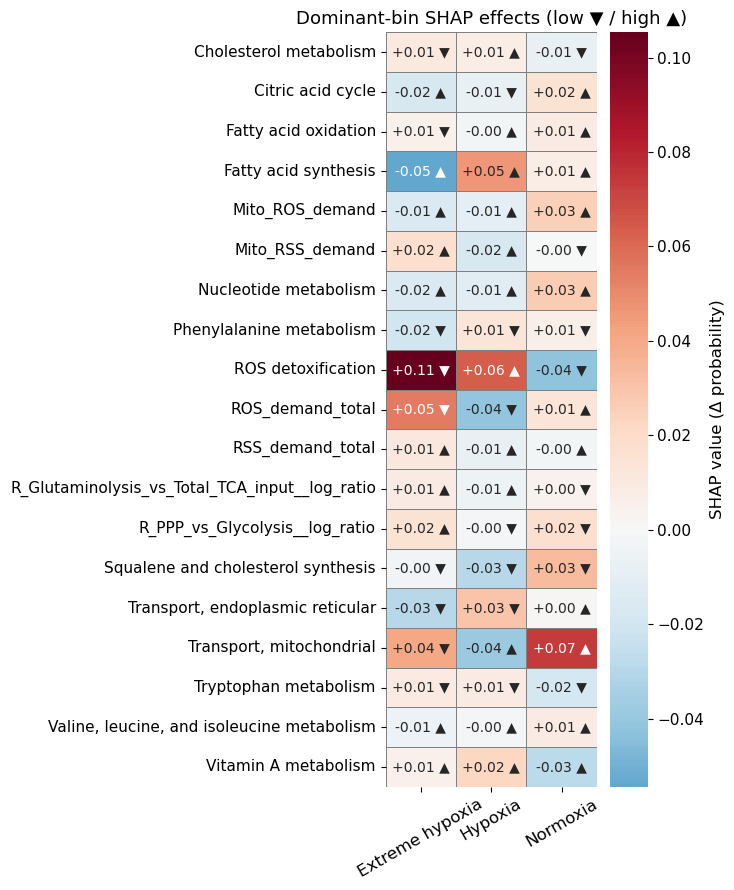

In [63]:
plot_low_high_shap_heatmap_arrows(dom_df,savepath=None)

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def shap_dependence_low_high(
    shap_exp,
    X,
    feature,
    class_names,
    target_class,
    figsize=(6, 4),
    alpha=0.4,
    savepath=None,
    fname=None,
    dpi=300,
):

    # class index
    k = list(class_names).index(target_class)

    # feature index and name
    if isinstance(feature, str):
        f_idx = X.columns.get_loc(feature)
        f_name = feature
    else:
        f_idx = feature
        f_name = X.columns[f_idx]

    x = X.iloc[:, f_idx].values
    y = shap_exp.values[:, f_idx, k]

    median = np.median(x)

    low_mask = x <= median
    high_mask = x > median

    low_mean = np.mean(y[low_mask]) if low_mask.any() else 0.0
    high_mean = np.mean(y[high_mask]) if high_mask.any() else 0.0

    plt.figure(figsize=figsize)

    # scatter
    plt.scatter(x, y, alpha=alpha)

    # median split
    plt.axvline(median, color="black", linestyle="--", lw=1)

    # mean SHAP lines
    plt.hlines(
        low_mean,
        xmin=np.min(x[low_mask]),
        xmax=np.max(x[low_mask]),
        colors="red",
        lw=3,
        label=f"Low mean SHAP = {low_mean:+.3f}",
    )

    plt.hlines(
        high_mean,
        xmin=np.min(x[high_mask]),
        xmax=np.max(x[high_mask]),
        colors="blue",
        lw=3,
        label=f"High mean SHAP = {high_mean:+.3f}",
    )

    plt.axhline(0, color="gray", lw=1)

    plt.xlabel(f_name)
    plt.ylabel(f"SHAP value (ΔP[{target_class}])")
    plt.title(f"Low/High SHAP dependence: {f_name} → {target_class}")
    plt.legend()
    plt.tight_layout()

    if savepath is not None:
        if fname is None:
            fname = f"shap_dependence_low_high_{f_name}_{target_class}".replace(" ", "_")
        plt.savefig(f"{savepath}/{fname}.pdf", dpi=dpi, bbox_inches="tight")
        plt.savefig(f"{savepath}/{fname}.jpg", dpi=dpi, bbox_inches="tight")

    plt.show()


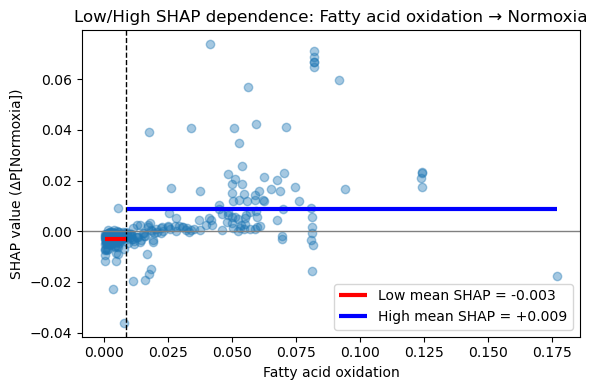

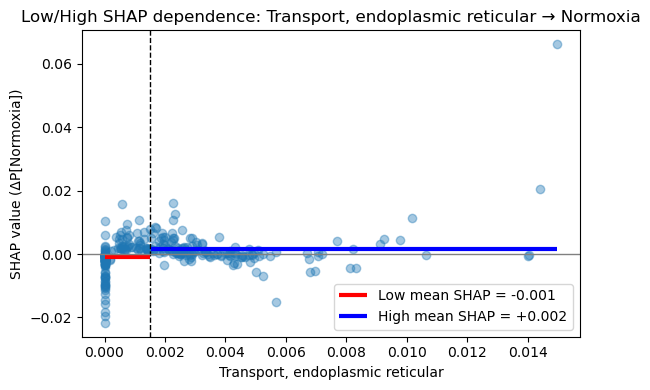

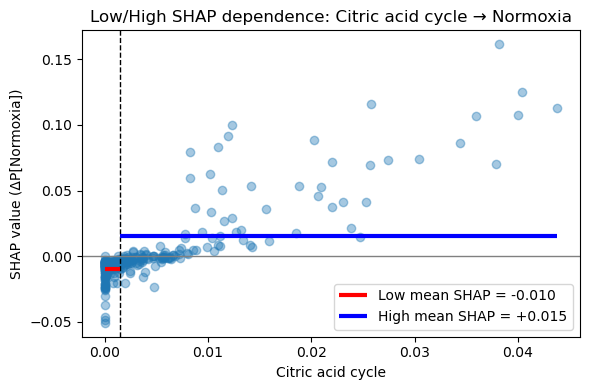

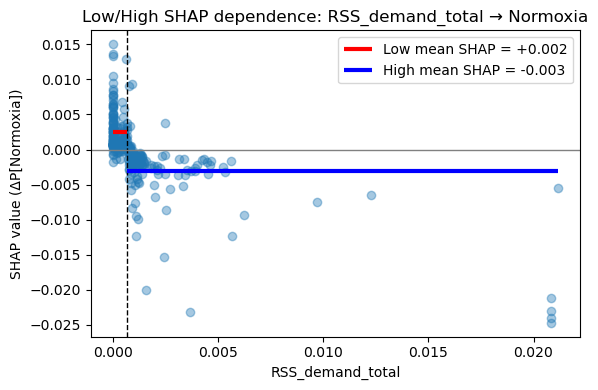

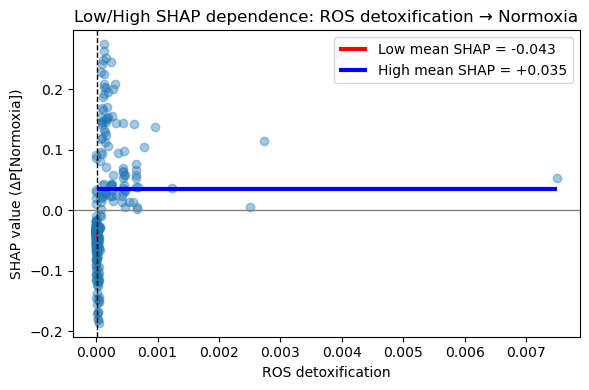

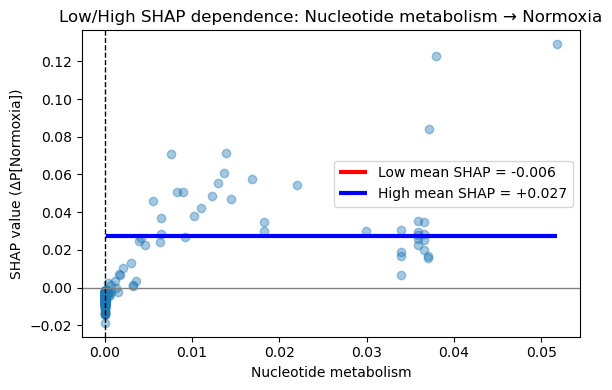

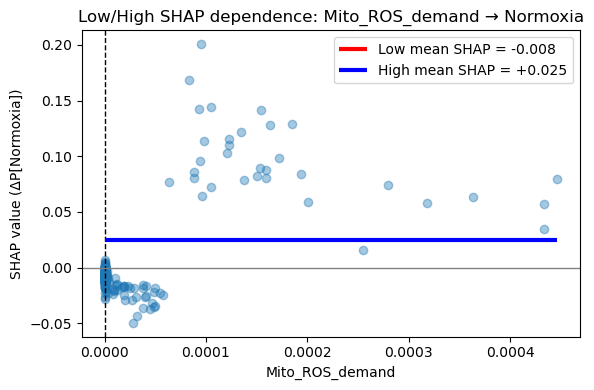

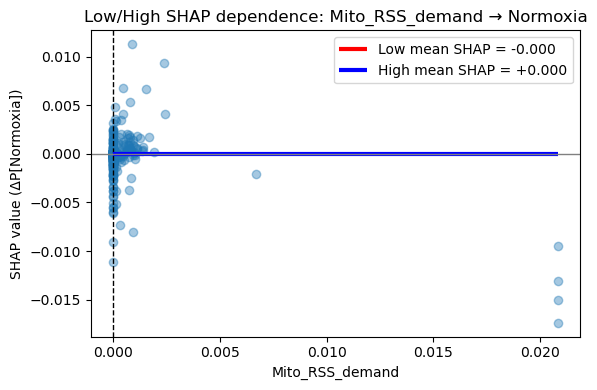

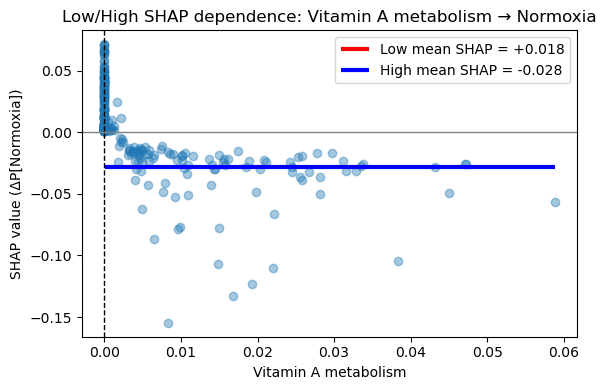

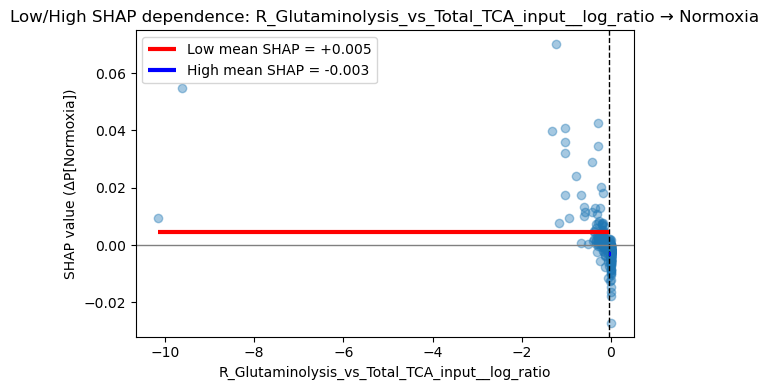

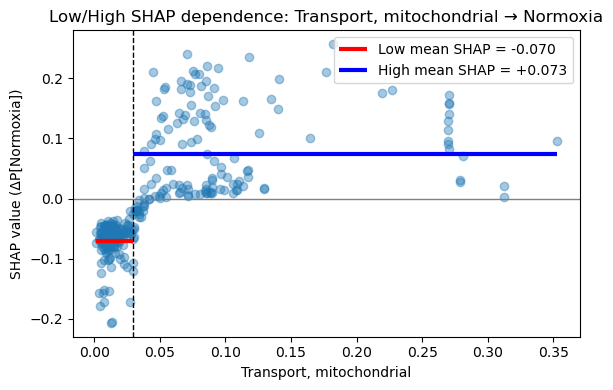

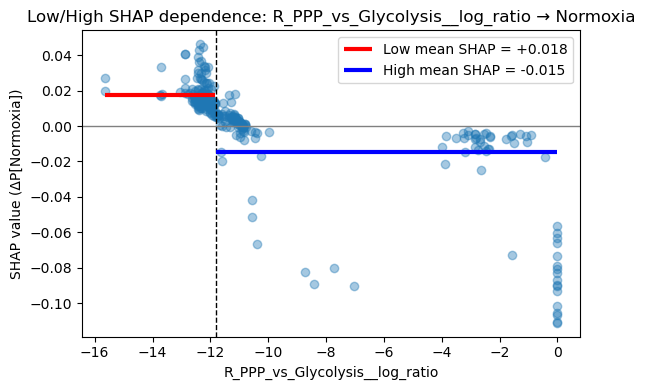

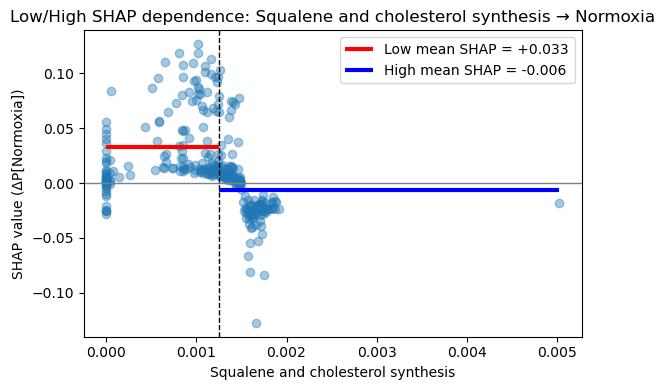

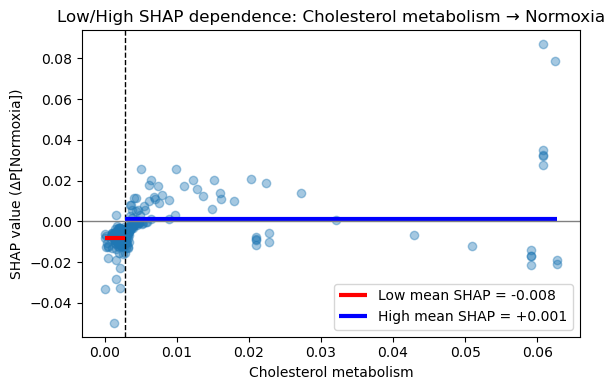

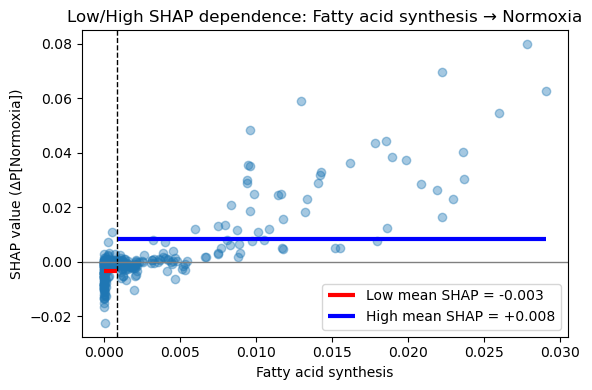

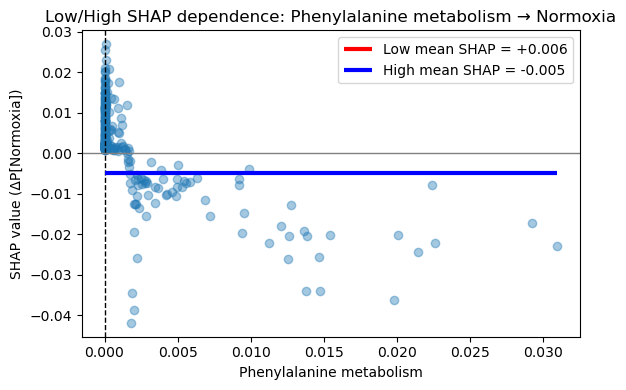

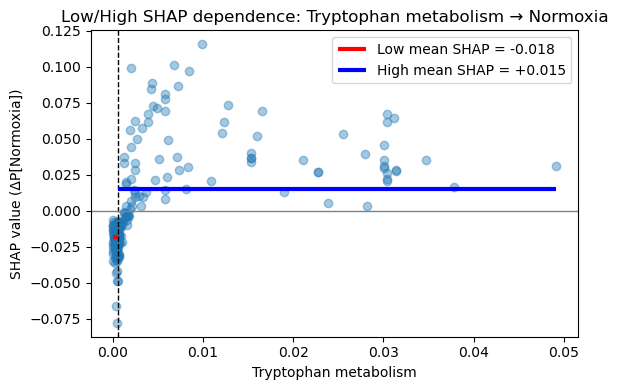

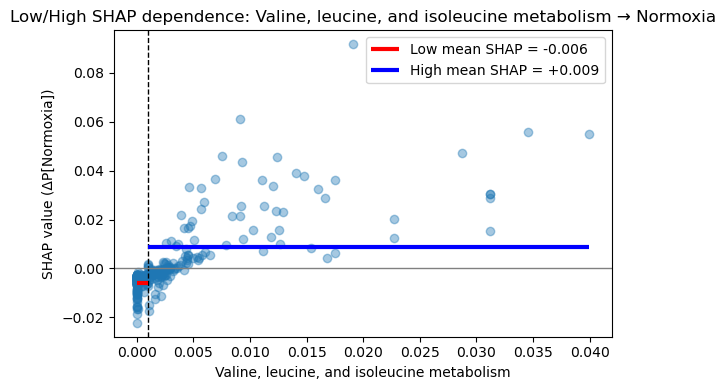

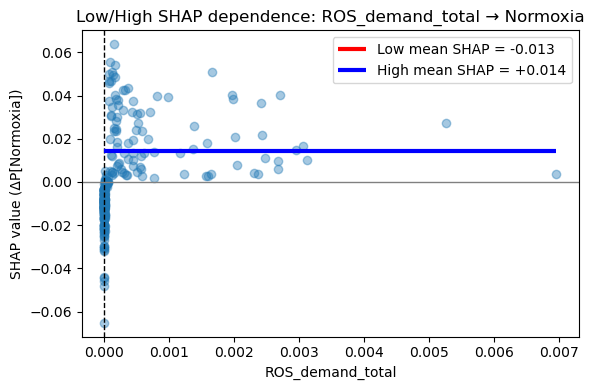

In [65]:
for feat in top_feats:
    shap_dependence_low_high(
        shap_exp=lgbm_shap,
        X=X_test,
        feature=feat,
        class_names=class_names,
        target_class="Normoxia",
        savepath=None)

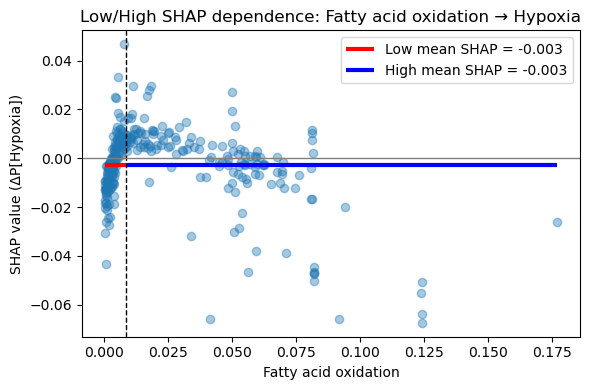

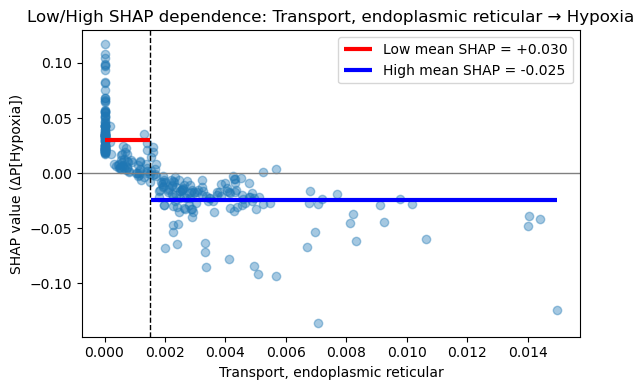

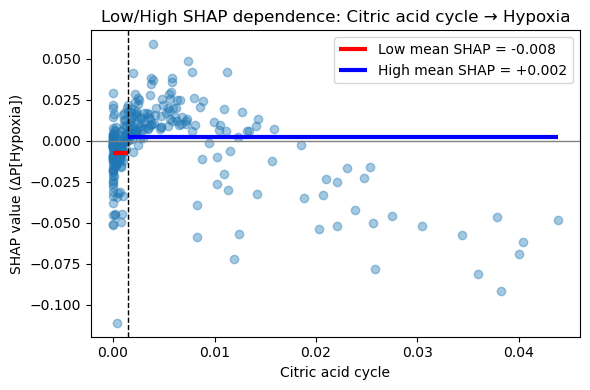

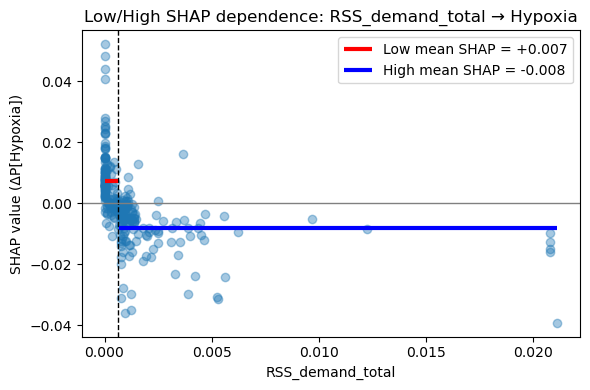

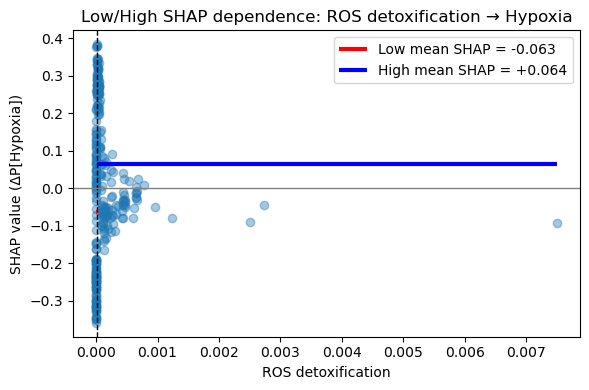

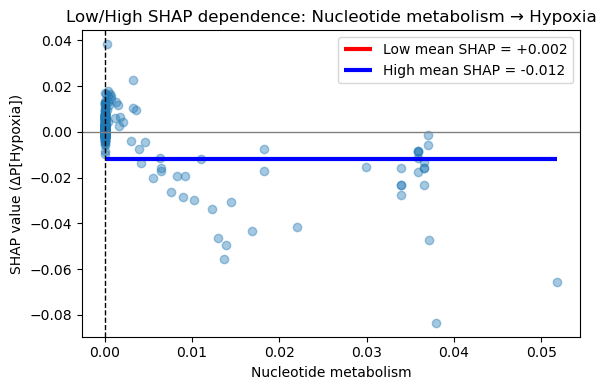

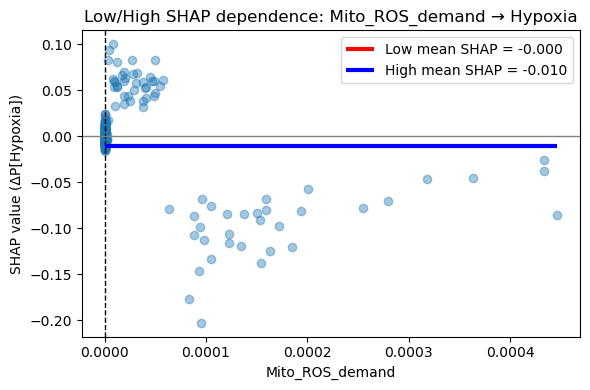

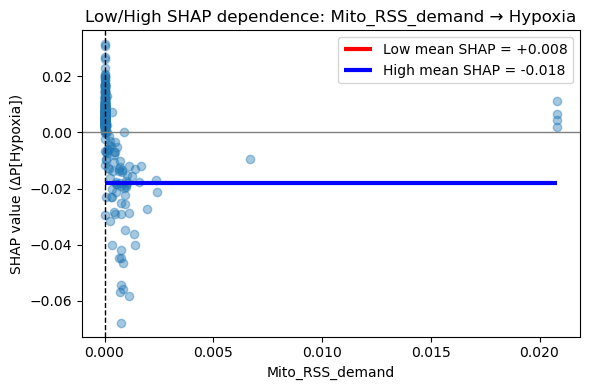

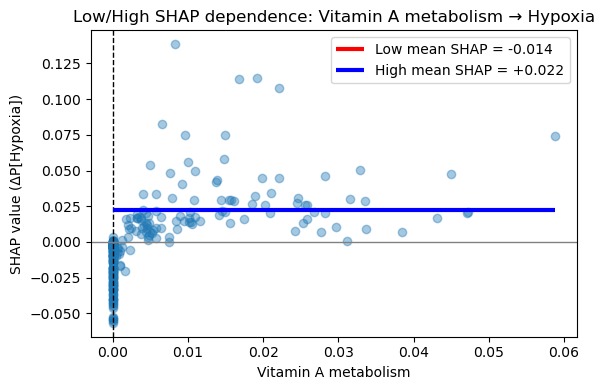

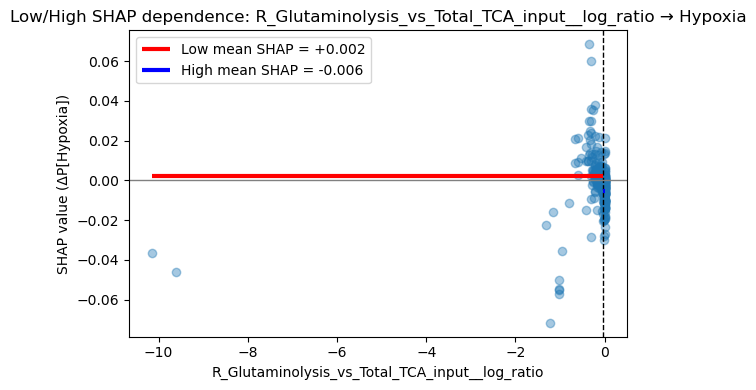

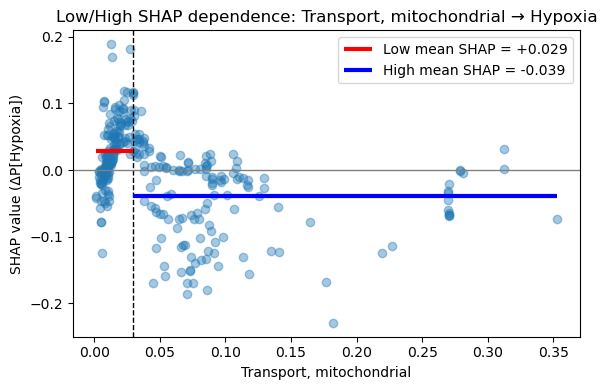

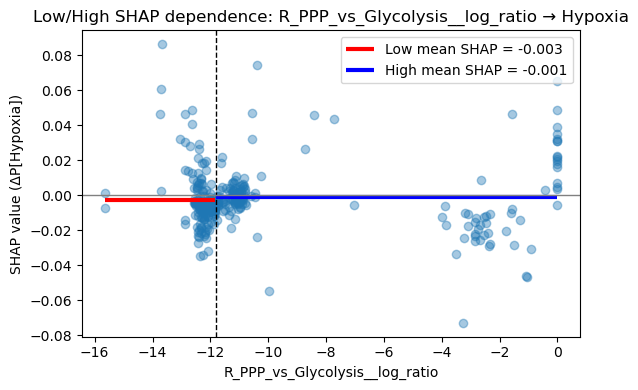

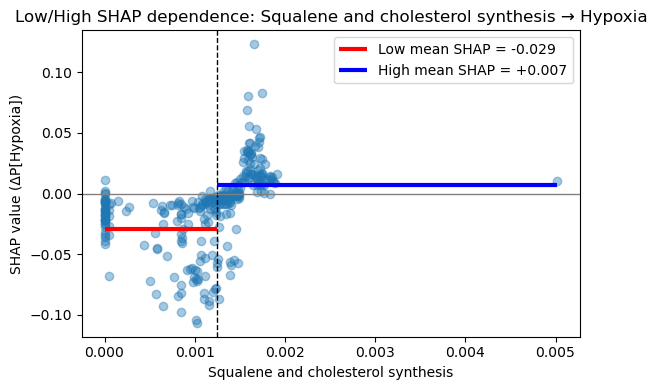

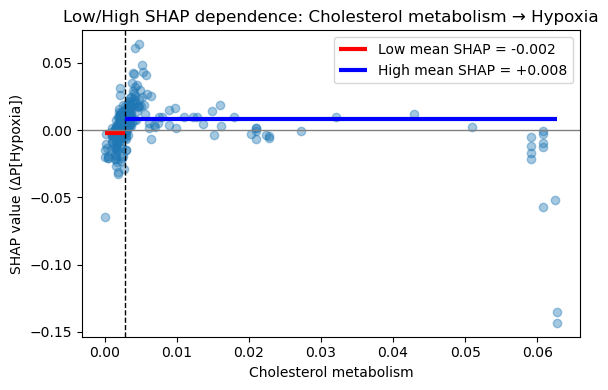

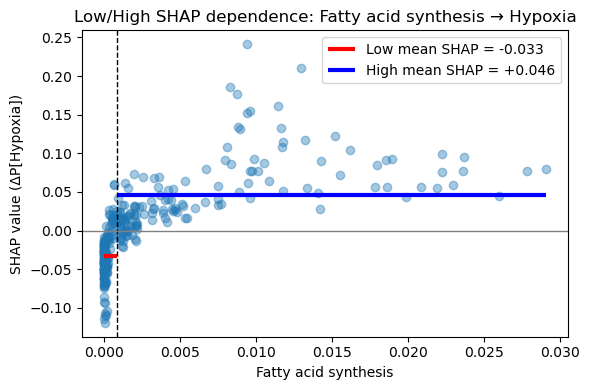

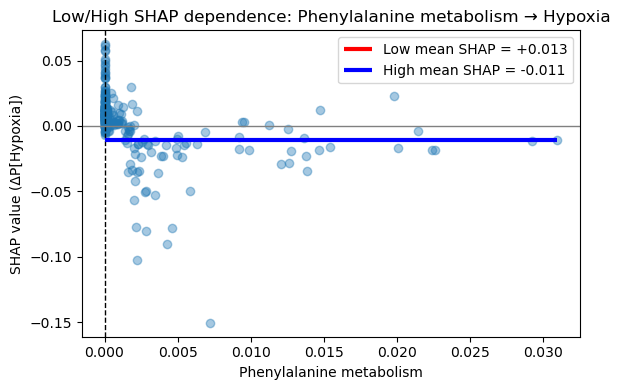

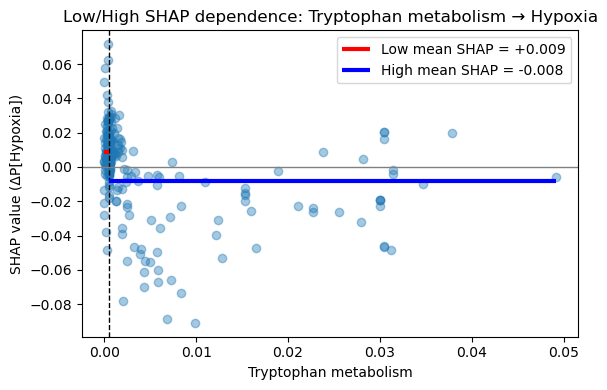

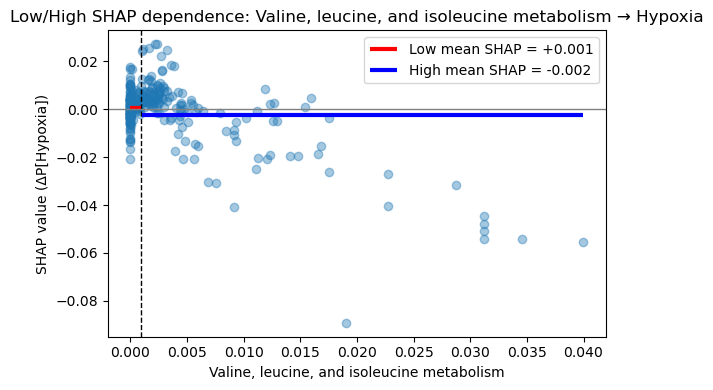

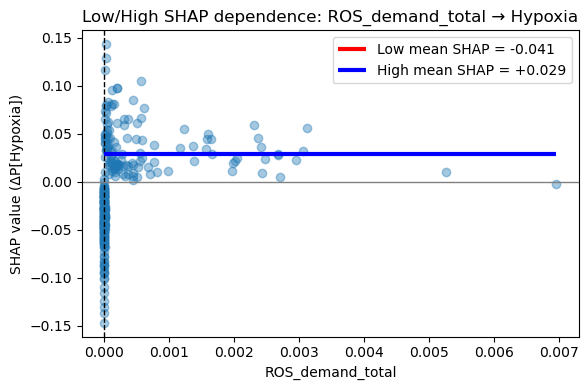

In [66]:
for feat in top_feats:
    shap_dependence_low_high(
        shap_exp=lgbm_shap,
        X=X_test,
        feature=feat,
        class_names=class_names,
        target_class="Hypoxia",
        savepath=None)

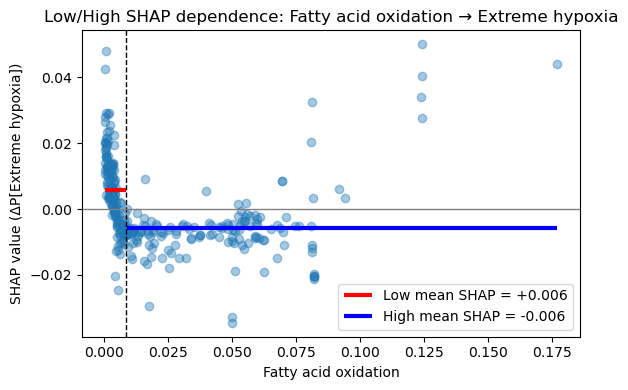

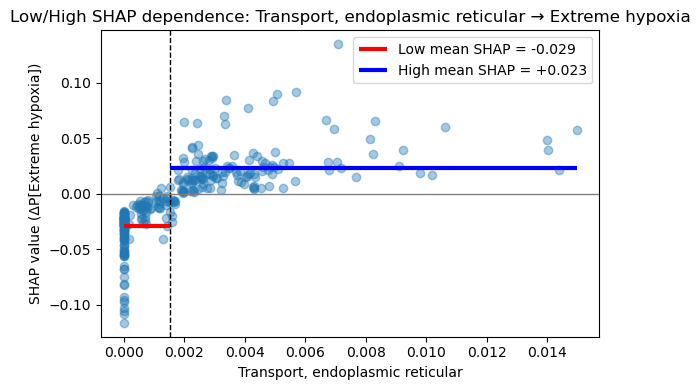

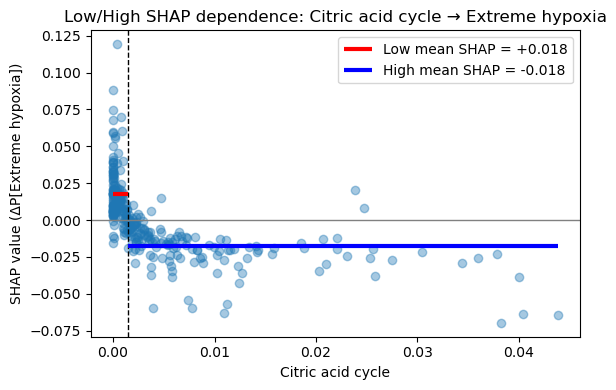

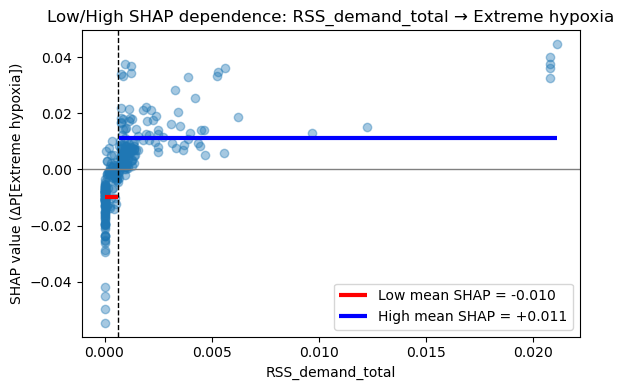

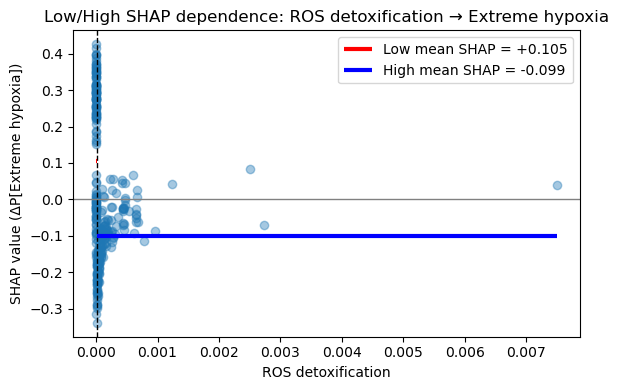

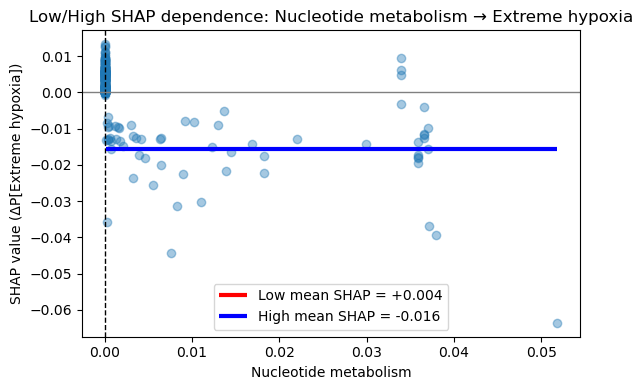

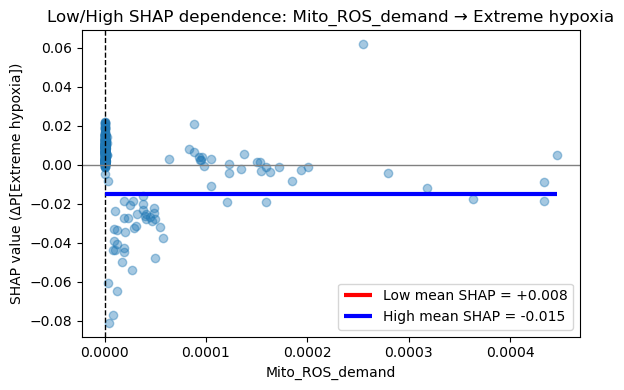

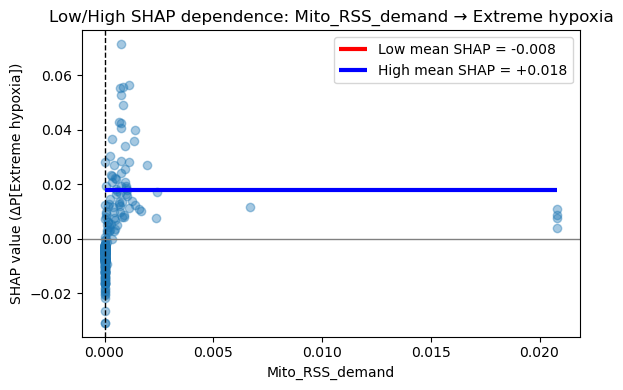

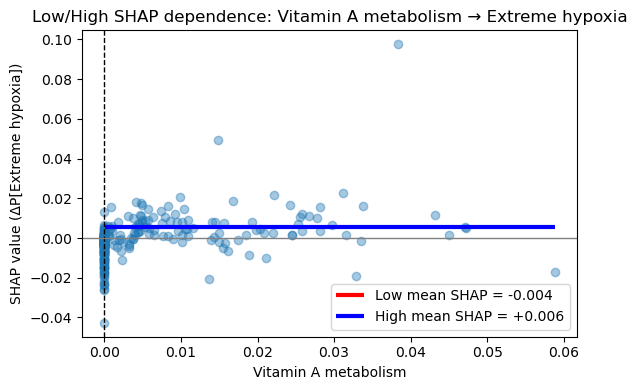

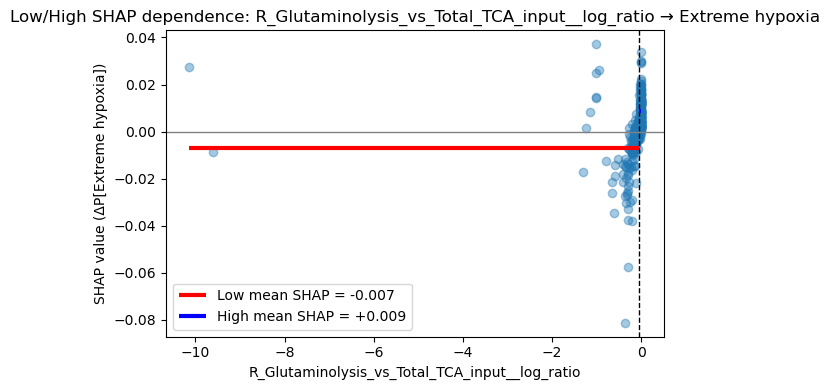

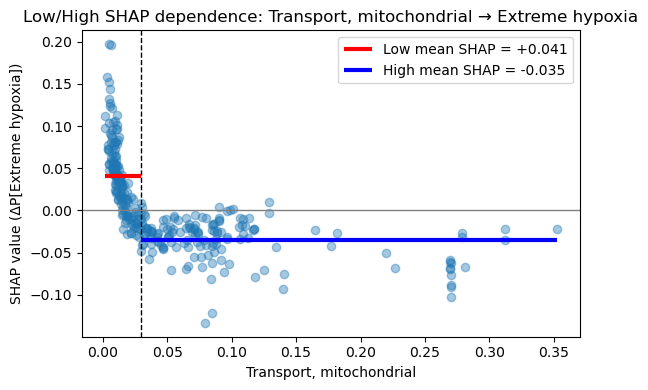

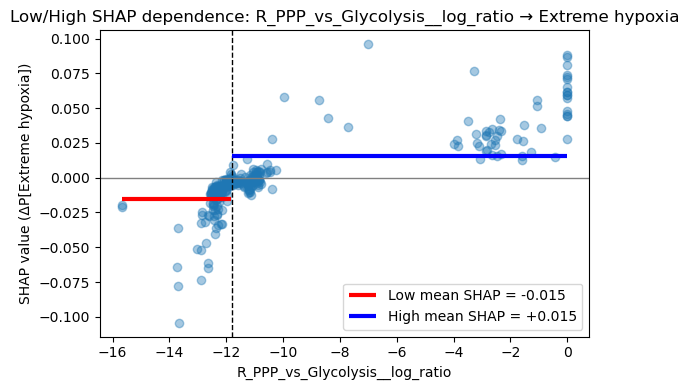

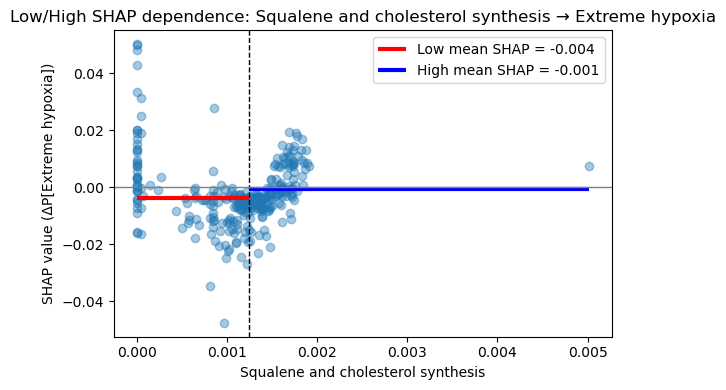

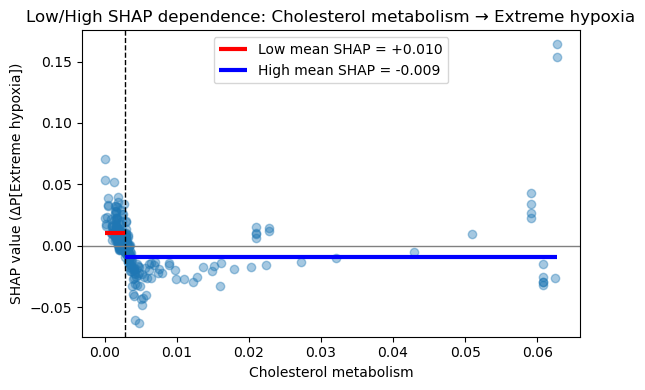

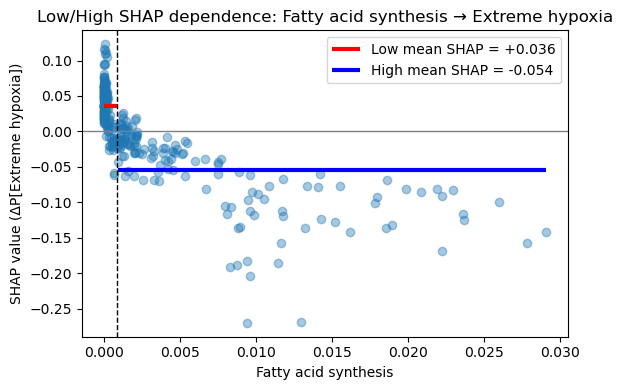

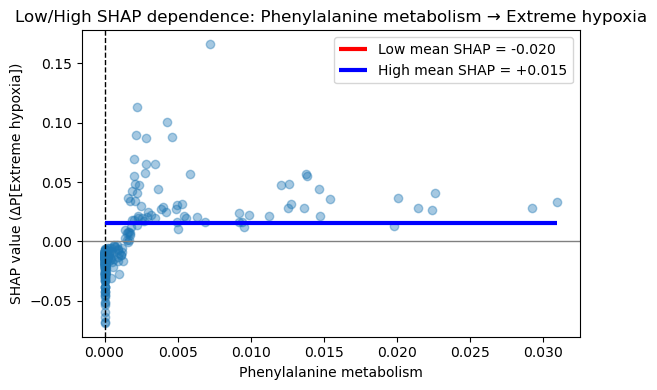

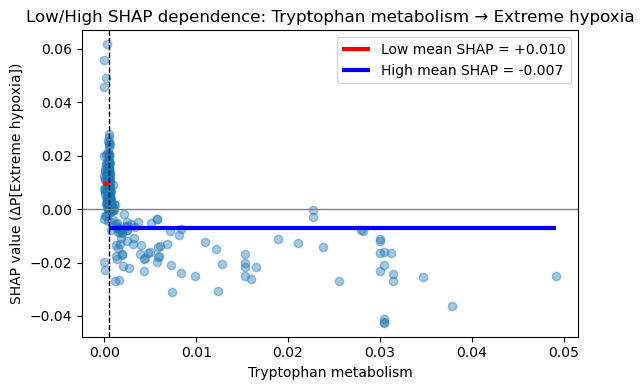

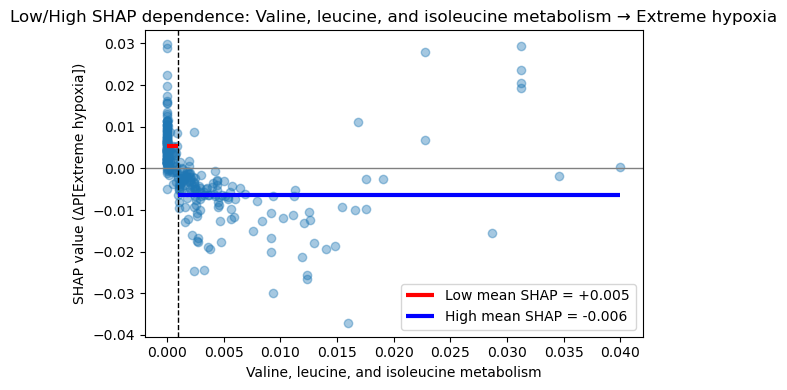

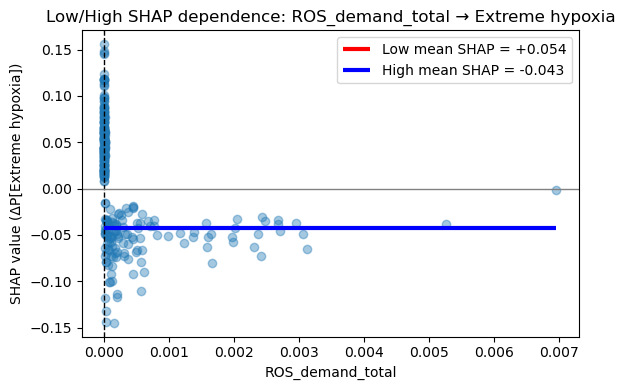

In [67]:
for feat in top_feats:
    shap_dependence_low_high(
        shap_exp=lgbm_shap,
        X=X_test,
        feature=feat,
        class_names=class_names,
        target_class="Extreme hypoxia",
        savepath=None)